<a href="https://colab.research.google.com/github/raphaelferreiravieira/Trabalho-Final/blob/Fase-4-Separacao%2C-Balanceamento-e-Escalonamento-Seguro/Trab_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Opção A: Risco de credito ( Setor Financeiro)**

Aluno: Raphael Ferreira Vieira



**Importação das bibliotecas necessárias para o trabalho**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    classification_report
)



**Importação de arquivo do tipo CSV considerando a Opção A para a realização do trabalho final, utilizando a função read_csv do Pandas e convertendo os dados num DataFrame.**


In [ ]:
df=pd.read_csv("credit_risk_dataset.csv")

A observacao da base de dados revela as seguintes colunas:

**person_age (Idade)**: Idade do cliente em anos;

**person_income (Rendimento Anual)**: Rendimento anual bruto do cliente por ano;

**person_home_ownership (Situação Habitacional)**: Tipo de posse de habitação do proponente, dividida em quatro categorias: RENT (Arrendado), MORTGAGE (Hipoteca/Crédito habitação), OWN (Casa própria) e OTHER (Outro);

**person_emp_length (Tempo de Emprego)**: Tempo de serviço ou experiência de trabalho do cliente em anos;

**loan_intent (Finalidade do Empréstimo)**: O motivo do pedido do empréstimo, classificado em seis categorias: Pessoal, Educação, Saúde, Negócios/Empreendedorismo, Obras/Remodelação e Consolidação de dívida;

**loan_grade (Classificação do Empréstimo):** Categoria de risco atribuída ao crédito pelo sistema de scoring, numa escala de A (menor risco) a G (maior risco);

**loan_amnt (Montante do Empréstimo):** Valor total do empréstimo solicitado pelo cliente em unidades monetarias;

**loan_int_rate (Taxa de Juro)**: Taxa de juro anual do empréstimo em percentagem;

**loan_percent_income**: Proporção do valor do empréstimo em relação ao rendimento anual do cliente;

**cb_person_default_on_file**: Indica se o cliente tem um histórico prévio de nao cumprimento/falha de pagamento;

**cb_person_cred_hist_length**: Anos de histórico de crédito registados no bureau desde a abertura da primeira conta/crédito do cliente, variando entre 2 e 30 anos.



# **Análise exploratória de dados (EDA) - FASE 1**

**1.Primeiramente, será visualizada a quantidade de linhas e colunas dos dados utilizando o comando shape, conforme descrito abaixo. Ao realizar o print, verifica-se que a base de dados contêm 32.581 linhas e 12 colunas.**

In [ ]:
print(f'O dado contem {df.shape[0]} linhas e {df.shape[1]} colunas')

O dado contem 32581 linhas e 12 colunas


**2. Após isso, optou-se por descrever o tipo de dado de cada coluna por meio da função info() do pandas. A informação da função revela que existem dados nulos (vazios) em algumas variáveis, como loan_int_rate e person_emp_length, e que os principais tipos de dados são int64, float64 e object.**

In [ ]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


**O comando head apresentou as primeiras linhas da base de dados**

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


**O comando describe() possibilita a análise estatística de cada uma das variáveis numéricas.**

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


**A variável-alvo desta base de dados é uma variável binária que indica se o cliente cumprirá ou não o pagamento (loan_status).
Quando o valor é 0, o cliente cumprirá o pagamento dentro do prazo; quando é 1, o cliente ficará inadimplente. Abaixo, é apresentado um gráfico com o percentual de casos de cada classe na base de dados escolhida.**

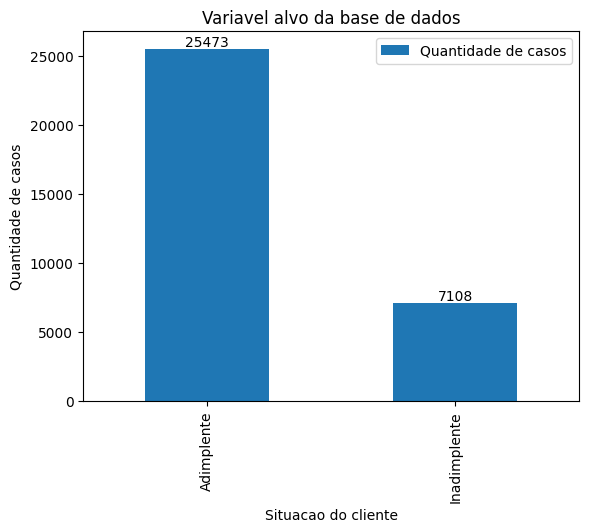

<Axes: title={'center': 'Variavel alvo da base de dados'}, xlabel='Situacao do cliente', ylabel='Quantidade de casos'>

In [ ]:
valores_target=df['loan_status'].value_counts().plot(kind='bar', legend=True)
plt.xticks([0,1],['Adimplente','Inadimplente'])
plt.legend(['Quantidade de casos'])
plt.title ('Variavel alvo da base de dados')
plt.xlabel('Situacao do cliente')
plt.ylabel('Quantidade de casos')
plt.bar_label(plt.gca().containers[0])
plt.show()
valores_target

**Observa-se um desbalanceamento moderado na variavel target, tendo em vista que a condição de pagamento adimplente é quase quatro vezes maior, em quantidade de dados, que a condição de inadimplente.**

In [ ]:
coluna_numer=df.select_dtypes(include=['float','int']).columns.tolist()
correlacao=df[coluna_numer].corr()
correlacao

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


**Abaixo, plotou-se o coeficiente de correlação de Pearson entre cada uma das variáveis. Importante ressaltar quer esse primeiro grafico permitiu a plotagem da correlacao sem no entanto que o tratamento de nulos, outliers, duplicadas, etc fosse feito, ou seja, e anterior a cada um desses tratamentos. Como as colunas loan_int_rate e person_emp_length a correlacao entre elas somente e calculada com dados que apresentam valores em ambas as colunas, ou seja, o tratamento de dados nulos nessa coluna pode ira alterar o valor da correlacao dessas variaveis.**

<Axes: >

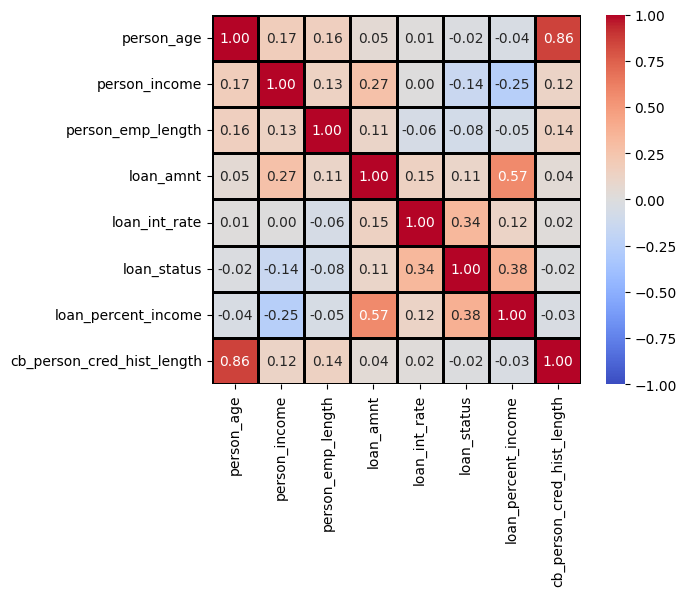

In [ ]:
sns.heatmap(data=correlacao, annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=1,
    linecolor="black",
    square=True,
    cbar=True,  )

**A análise da correlação entre as variaveis numericas e o target revela que:**

• loan_percent_income (+0,38): Quanto mais o rendimento é comprometido com o empréstimo, maior é a probabilidade de inadimplência.

• loan_int_rate (+0,34): Quanto maior a taxa de juros, maior é a probabilidade de o cliente ficar inadimplente.

• person_income (-0,14): Maiores rendimentos diminuem a probabilidade de inadimplência.

• loan_amnt (+0,11): Empréstimos maiores aumentam o risco de inadimplência.

• person_emp_length (-0,08): Maior estabilidade no emprego indica menor risco de inadimplência.

• person_age (-0,02): Sem correlação significativa.

• cb_person_cred_hist_length (-0,02): Sem correlação significativa.


**Para conhecer melhor os dados nessa etapa serão plotados gráficos como o histograma de distribuição de idades e o histograma faixas de renda bruta anual.**

**Distribuicao de idades**

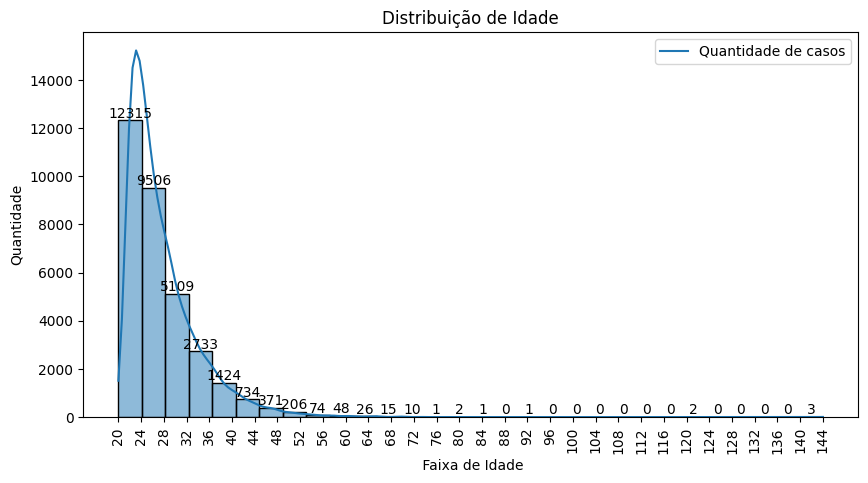

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='person_age', kde=True, bins=30, legend=True)
plt.legend(['Quantidade de casos'])
plt.title('Distribuição de Idade')
plt.xlabel(' Faixa de Idade')
plt.ylabel('Quantidade')
min_x = int(df["person_age"].min())
max_x = int(df["person_age"].max())
ticks= np.arange(min_x, max_x + 4, 4)
plt.xticks(ticks,rotation=90)
plt.bar_label(plt.gca().containers[0])
plt.show()

**Histograma de renda bruta por ano. Observa-se a presenca de um outlier elevado que distorce um pouco a escala do histograma**.

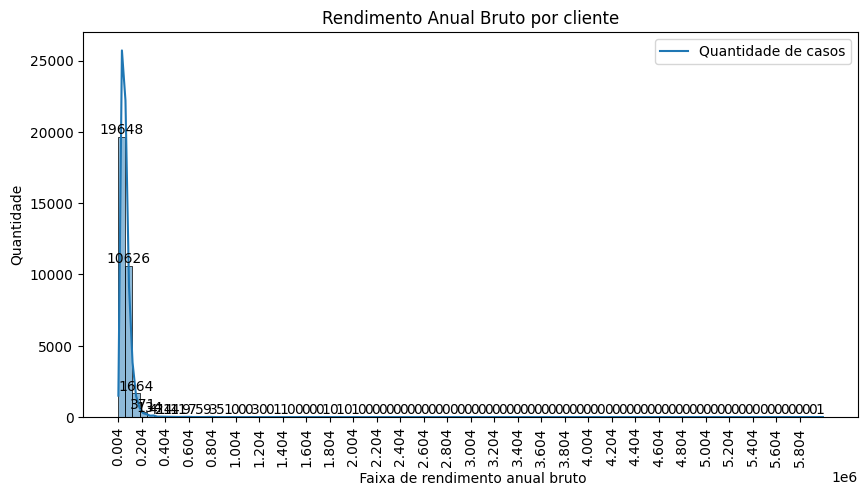

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='person_income', kde=True, bins=100, legend=True)
plt.legend(['Quantidade de casos'])
plt.title('Rendimento Anual Bruto por cliente')
plt.xlabel(' Faixa de rendimento anual bruto')
plt.ylabel('Quantidade')
min_x = int(df["person_income"].min())
max_x = int(df["person_income"].max())
ticks= np.arange(min_x, max_x, 200000)
plt.xticks(ticks,rotation=90)
plt.bar_label(plt.gca().containers[0])
plt.show()

# **FASE 2- Tratamento e Limpeza (DATA PREP)**

**Com o objetivo de visualizar melhor a quantidade de dados nulos, optou-se por plotar um gráfico de barras indicando a quantidade dessas ocorrências por coluna, o qual é evidenciado abaixo.**

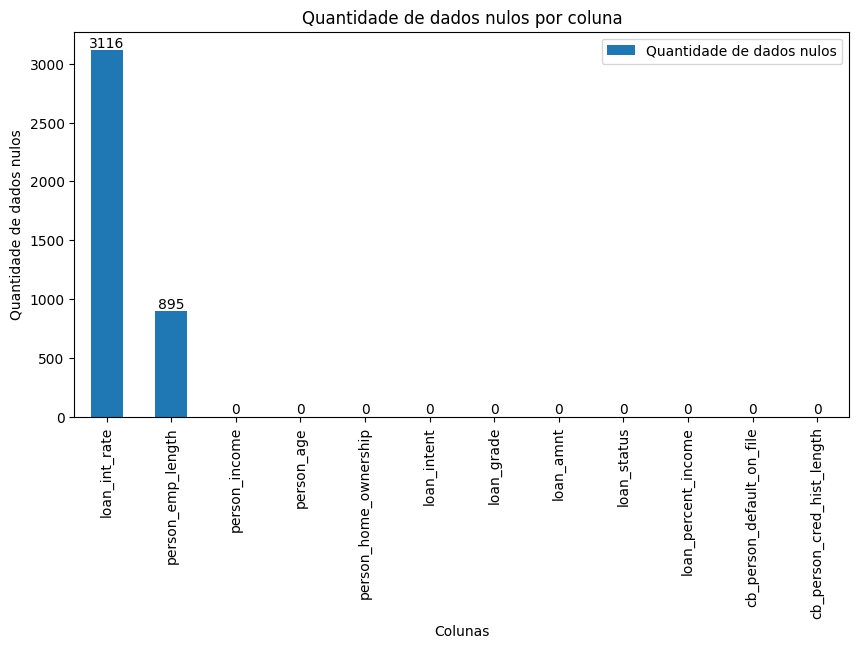

In [ ]:
plt.figure(figsize=(10,5))
df.isna().sum().sort_values(ascending=False).plot(kind='bar', legend=True)
plt.legend(['Quantidade de dados nulos'])
plt.title('Quantidade de dados nulos por coluna')
plt.xlabel('Colunas')
plt.ylabel('Quantidade de dados nulos')
plt.bar_label(plt.gca().containers[0])
plt.show()

**Como parte do processo de ETL, os dados nulos terão que ser tratados posteriormente para, após isso, serem utilizados pelo modelo de IA. Em momento oportuno deste código, será definido se esses dados terão um valor imputado ou se serão simplesmente eliminados da base de dados.**

**É importante também observar se a base de dados apresenta dados duplicados e, se sim, realizar o tratamento dos mesmos. Para isso, pode ser utilizada a função duplicated() do pandas.**

In [ ]:
print(f'O numero de linhas duplicadas e de {df.duplicated().sum()}.')

O numero de linhas duplicadas e de 165.


Aqui uma pergunta surge. Faz sentido existirem linhas duplicadas nesta base de dados?

**1. Para esse caso em questao nao existe uma coluna de identificador da pessoa. Caso existisse, colunas com o mesmo identificador poderiam indicar 2 propostas diferentes para o mesmo cliente. Sem um ID, todas as 12 variáveis — desde a idade, rendimento, montante, taxa de juro até ao histórico de crédito apontam para uma duplicacao acidental ou fruto da extracao do dado.**

**Dessa forma, os dados serão excluídos com o intuito, também, de evitar futuros vazamentos de dados do treino para o teste fruto da duplicação. Para isso, será utilizada a função drop_duplicates().**

In [ ]:
df=df.drop_duplicates()
print(f'O numero de linhas duplicadas e de {df.duplicated().sum()}. Agora o numero de linhas e de {df.shape[0]}')

O numero de linhas duplicadas e de 0. Agora o numero de linhas e de 32416


**Tratamento de dados nulos**

Conforme já indicado, as colunas loan_int_rate e person_emp_length apresentam dados nulos. A coluna loan_int_rate indica a taxa de juros anual do empréstimo, enquanto person_emp_length indica o tempo de serviço do cliente em anos.

Primeiramente, é importante verificar qual o percentual de linhas que apresentam dados nulos em relação ao restante da base de dados.

In [ ]:
valores_nulos=df.isna().sum().reset_index()
valores_nulos.rename(columns={'index':'colunas',0:'Percentual_nulos'}, inplace=True)
valores_nulos['Percentual_nulos']=(valores_nulos['Percentual_nulos']/df.shape[0])*100
valores_nulos

,colunas,Percentual_nulos
0,person_age,0.000000
1,person_income,0.000000
2,person_home_ownership,0.000000
3,person_emp_length,2.736303
4,loan_intent,0.000000
5,loan_grade,0.000000
6,loan_amnt,0.000000
7,loan_int_rate,9.547754
8,loan_status,0.000000
9,loan_percent_income,0.000000


**Cerca de  9,6 % dos dados de taxa de juros e 2,7% da coluna person_emp_length se encontram com valores nulos**

Dado o volume de dados da base, a eliminação desses registros não será uma opção. Em caso de exclusão, o modelo perderia muitos dados, reduzindo sua capacidade estatística de prever novos resultados.

Observando-se os gráficos de boxplot e o histograma demonstrados abaixo, é possível observar ainda a presença de outliers elevados, provocando distorções entre média e mediana. Ainda ocorre impacto no algoritmo KNN, pois o mesmo trabalha com distâncias euclidianas entre os pontos em um espaço multidimensional.

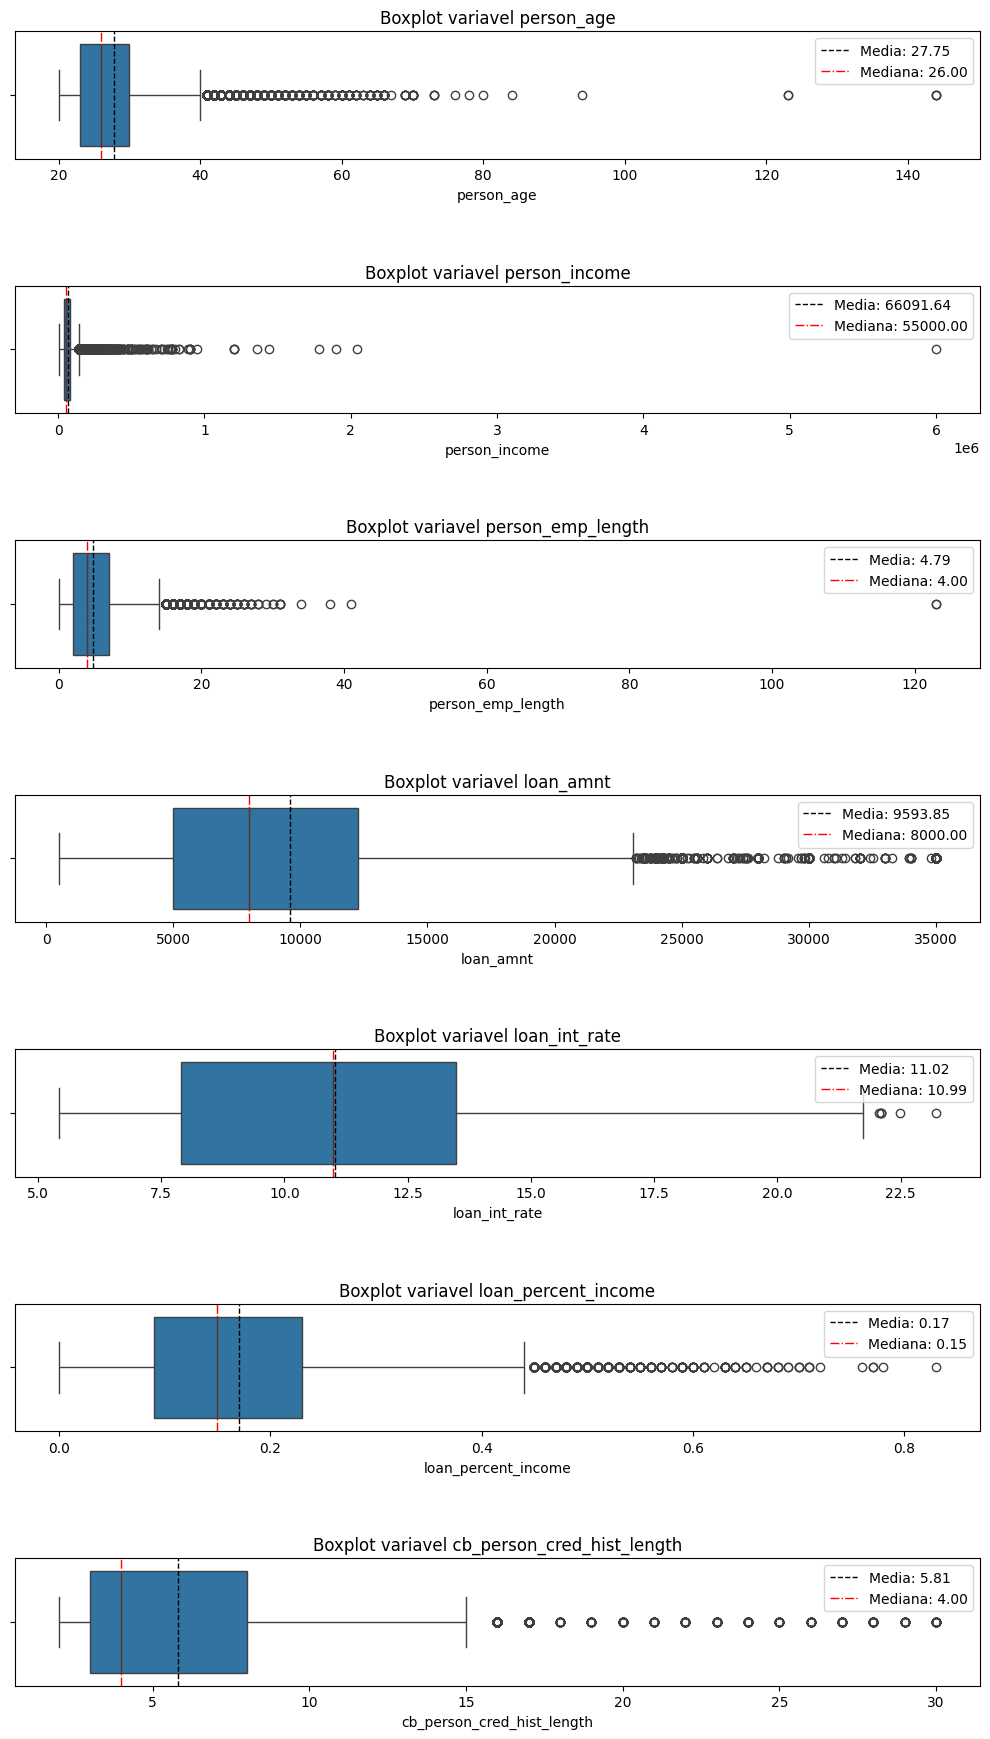

In [ ]:
# Filtrando as colunas numericas da base de dados e transformando em uma lista

variaveis_numericas=df.select_dtypes(include=[int,float]).columns.tolist()

# Retirando a variavel Target
variaveis_numericas.remove("loan_status")
fig,axes=plt.subplots(len(variaveis_numericas),1,figsize=(10,17.5))
i=0
for variavel in variaveis_numericas:
  sns.boxplot(data=df, x=variavel,ax=axes[i])
  axes[i].set_title(f'Boxplot variavel {variavel}')
  axes[i].axvline(color='Black', linestyle='--',linewidth='1', x=df[variavel].mean(),label=f'Media: {df[variavel].mean():.2f}')
  axes[i].axvline(color='Red', linestyle='-.',linewidth='1', x=df[variavel].median(), label=f'Mediana: {df[variavel].median():.2f}')
  axes[i].legend()
  i+=1
plt.tight_layout()
plt.subplots_adjust(wspace=1, hspace=1)
plt.show()

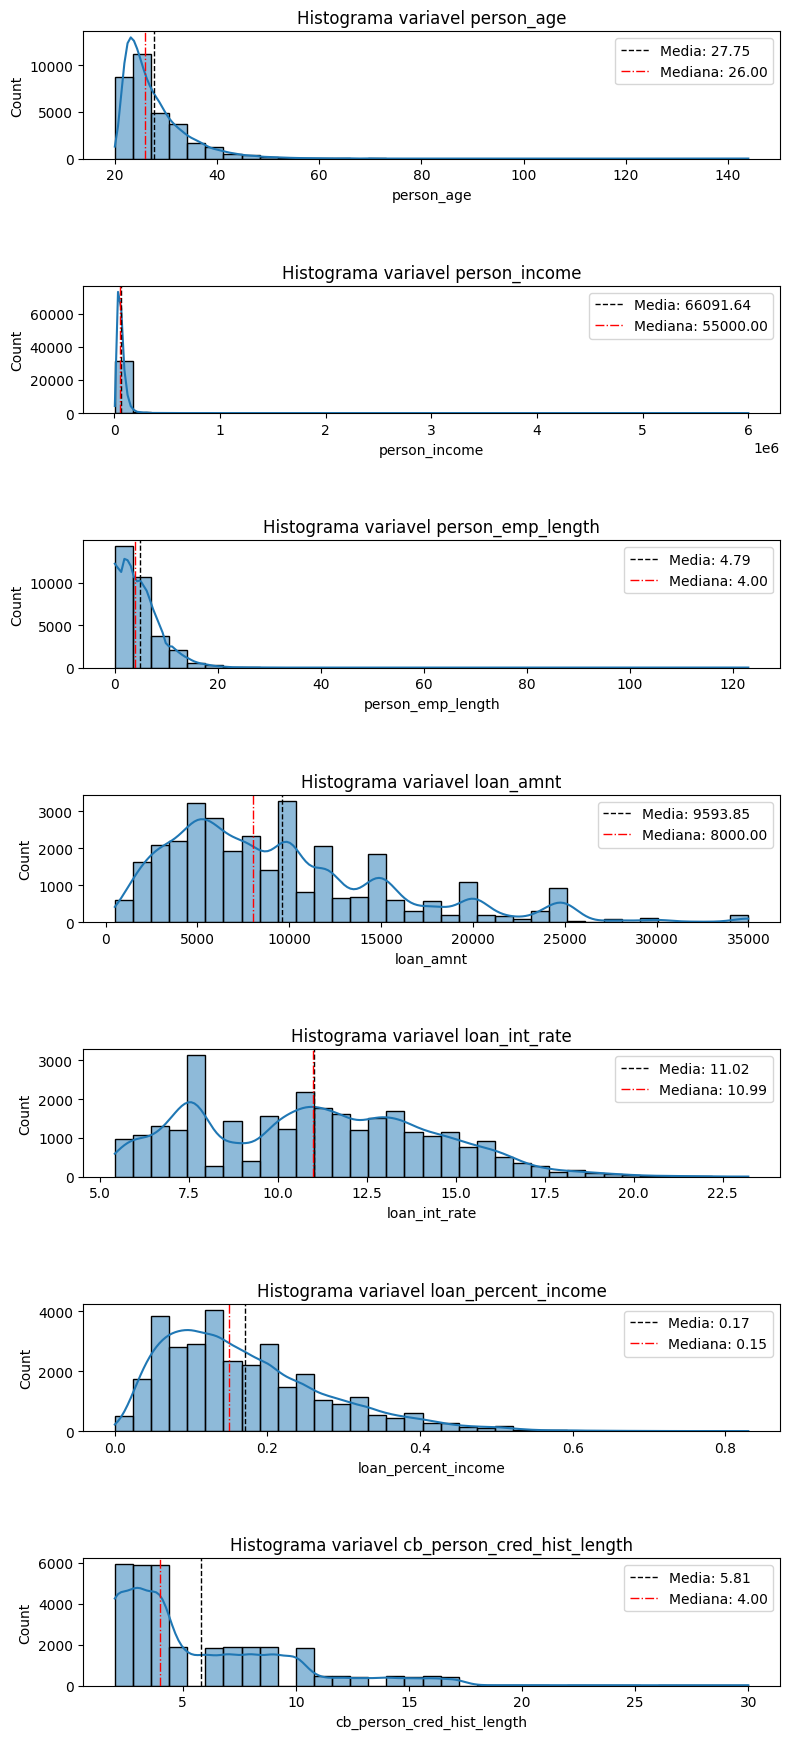

In [ ]:

fig,axes=plt.subplots(len(variaveis_numericas),1,figsize=(8,17.5))
i=0
for variavel in variaveis_numericas:
  sns.histplot(data=df, x=variavel,ax=axes[i], bins=35, kde=True)
  axes[i].set_title(f'Histograma variavel {variavel}')
  axes[i].axvline(color='Black', linestyle='--',linewidth='1', x=df[variavel].mean(),label=f'Media: {df[variavel].mean():.2f}')
  axes[i].axvline(color='Red', linestyle='-.',linewidth='1', x=df[variavel].median(), label=f'Mediana: {df[variavel].median():.2f}')
  axes[i].legend()
  i+=1
plt.tight_layout()
plt.subplots_adjust(wspace=1, hspace=1)
plt.show()

**Tratamento de OUTLIERS**

**Outliers: eliminando apenas casos específicos sem usar a regra interquartil**

**Para as colunas:**

• person_income: Os outliers serão mantidos, pois a coluna representa o rendimento anual bruto do cliente, salvo a renda anual máxima, que chega a US$ 6.000.000,00 e terá esse registro discrepante excluído.

• person_emp_length: A coluna apresenta valores maiores que 120 anos, o que é fisicamente impossível, podendo estar relacionado a uma inserção incorreta de dados.

• loan_amnt: Correspondendo ao valor total do empréstimo, constata-se que o dado é fisicamente possível, mesmo aparecendo como um outlier.

• loan_int_rate: Para a taxa de juros anual, embora o gráfico indique a presença de outliers, estes serão mantidos por serem valores fisicamente possíveis.

• loan_percent_income: Representando a proporção do empréstimo em relação ao rendimento anual do cliente, os outliers também serão mantidos, pois a situação pode ocorrer na realidade.

• cb_person_cred_hist_length: Os anos do histórico de crédito também serão mantidos.

• person_age: Apresenta valores pouco coerentes para a idade de um cliente ativo.

Resumo das ações:
Serão excluídos apenas os dados da coluna person_emp_length que apresentarem mais de 120 anos, pois a situação é fisicamente impossível de ocorrer, caracterizando um erro de preenchimento alem de limitar a valores de ate 35 anos. A coluna person_age terá seus valores limitados a 100 anos. Por fim, a coluna person_income terá o seu valor discrepante máximo removido.


In [ ]:
colun_numer=df.select_dtypes(include=[int,float]).columns.tolist()
colun_numer.remove('loan_status')
colun_numer

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length']

**Eliminacao de usuarios com idade maior que 100 anos**



In [ ]:
df_80_anos=df[df['person_age']>80]
df=df[df['person_age']<=80] # Eliminando idados acima de 100
print(f'Apos toda a eliminacao de dados ficaram {df.shape[0]} dados')
print(f'Foram eliminados {df_80_anos.shape[0]} dados')


Apos toda a eliminacao de dados ficaram 32409 dados
Foram eliminados 7 dados


In [ ]:
# Verificacao inconsistencia idade x tempo de trabalho
j=0
for i,row in df.iterrows():
  if row['person_age']<=row['person_emp_length']:
    j+=1
print(f'Foram encontrados {j} dados nos quais a idade e menor que o tempo de servico. Esses dados serao dropados')

Foram encontrados 2 dados nos quais a idade e menor que o tempo de servico. Esses dados serao dropados


In [ ]:
#Dropando linhas nos quais idade e menor que o tempo de servico
for i,row in df.iterrows():
  if row['person_age']<=row['person_emp_length']:
    df.drop(i,inplace=True)
print(f'Existem {df.shape[0]} dados apos essa eliminacao')


Existem 32407 dados apos essa eliminacao


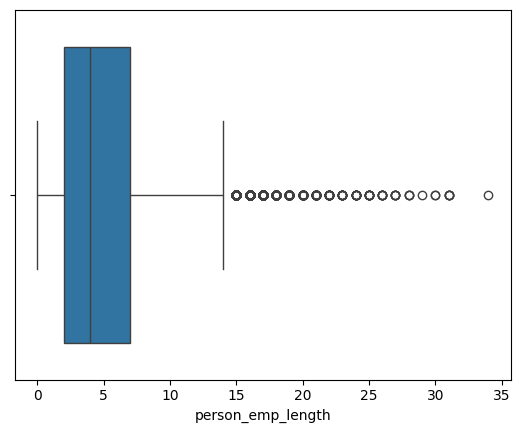

In [ ]:
linhas_eliminadas=len(df[df['person_emp_length']>35])
df=df[(df['person_emp_length']<=35) | (df['person_emp_length'].isna())]
sns.boxplot(data=df, x='person_emp_length')
plt.show()

In [ ]:
print(f'A elminacao dos outliers da coluna person_emp_length trouxe a eliminacao de {linhas_eliminadas} linhas restando {df.shape[0]} linhas na base de dados')

A elminacao dos outliers da coluna person_emp_length trouxe a eliminacao de 2 linhas restando 32405 linhas na base de dados


In [ ]:
df=df[df['person_income']<6000000] # Eliminando
print(f'Apos toda a eliminacao de dados ficaram {df.shape[0]} dados')

Apos toda a eliminacao de dados ficaram 32405 dados


**Tratamento dos dados NULOS**





**Voltando aos dados nulos foi identificado que as colunas loan_int_rate e person_emp_lenght apresentam valores nulos.**

Para uma primeira analise optou-se por plotar os graficos de boxplot e histograma das 2 variaveis separamente onde e possivel verificar que a coluna person_emp_length e Fortemente Assimétrica à Direita (Assimetria Positiva) enquanto a coluna loan_int_rate e Ligeiramente Assimétrica à Direita e Multimodal. Para esses casos nao e aconselhavel a imputacao de media ja que o valor da media acaba tambem sendo influenciada pelos outliers**



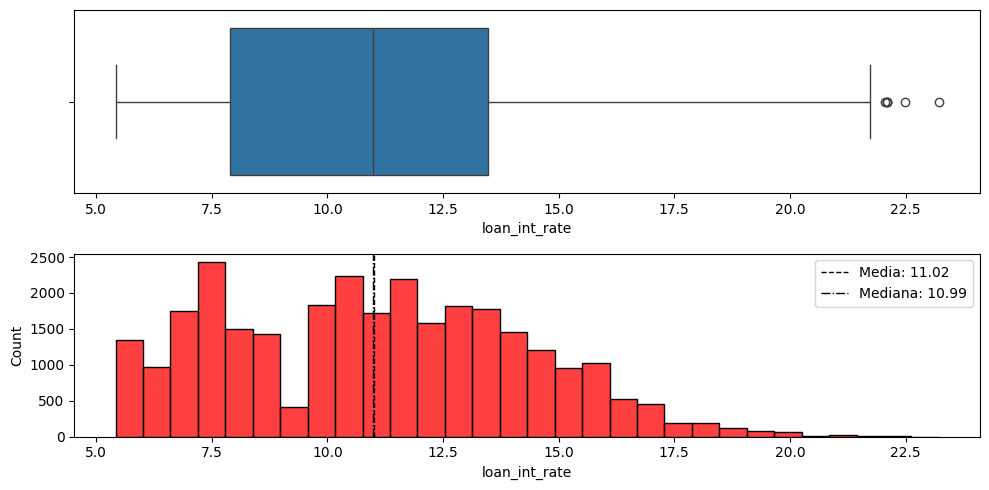

In [ ]:
variaveis=['loan_int_rate','person_emp_length']
fig,axes=plt.subplots(2,1,figsize=(10,5))
sns.boxplot(data=df, x='loan_int_rate',ax=axes[0])
sns.histplot(data=df,x='loan_int_rate',ax=axes[1],color='red',bins=30)
axes[1].axvline(color='Black', linestyle='--',linewidth='1', x=df['loan_int_rate'].mean(), label=f'Media: {df["loan_int_rate"].mean():.2f}')
axes[1].axvline(color='Black', linestyle='-.',linewidth='1', x=df['loan_int_rate'].median(), label=f'Mediana: {df["loan_int_rate"].median():.2f}')
axes[1].legend()
plt.tight_layout()
plt.show()

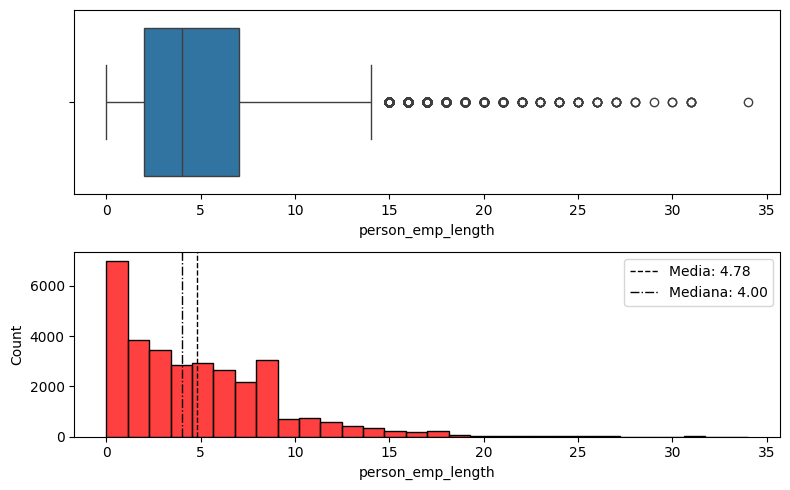

In [ ]:
variaveis=['loan_int_rate','person_emp_length']
fig,axes=plt.subplots(2,1,figsize=(8,5))
sns.boxplot(data=df, x='person_emp_length',ax=axes[0])
sns.histplot(data=df,x='person_emp_length',ax=axes[1],color='red',bins=30)
axes[1].axvline(color='Black', linestyle='--',linewidth='1', x=df['person_emp_length'].mean(), label=f'Media: {df["person_emp_length"].mean():.2f}')
axes[1].axvline(color='Black', linestyle='-.',linewidth='1', x=df['person_emp_length'].median(),label=f'Mediana: {df["person_emp_length"].median():.2f}')
axes[1].legend()
plt.tight_layout()
plt.show()

**REGRA DE IMPUTACAO DE DADOS PARA A COLUNA PERSON_EMP_LENGTH**

**Para a coluna person_emp_length optara-se por atribuir a mediana por idade (age_person) para se ter dados mais coerentes com a idade demonstrada nos dados.**

A mediana global dos dados e de 4.Se por exemplo esse dado fosse imputado para um individuo de 18 anos seria considerado que esse individuo comecou a trabalhar com 14 anos, o que nao e logico.

In [ ]:
Mediana=df.groupby('person_age')['person_emp_length'].median()
Med=Mediana.reset_index()

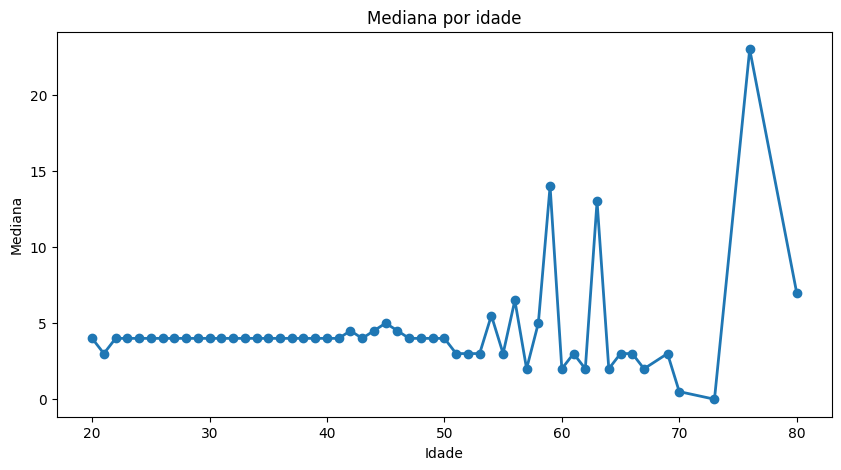

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    Med['person_age'],
    Med['person_emp_length'],
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Vendas',
)
plt.title('Mediana por idade')
plt.xlabel('Idade')
plt.ylabel('Mediana')
plt.show()

In [ ]:
df['person_emp_length'] = df.apply(lambda x: Mediana[x['person_age']] if np.isnan(x['person_emp_length']) else x['person_emp_length'], axis=1)
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3093
loan_status,0
loan_percent_income,0


**Para a coluna loan_int_rate, a taxa de juro está diretamente relacionada com a nota de risco/classificação do empréstimo. Ou seja quanto maior o risco maior a taxa de juros. Nesse sentido sera imputado a mediana dos dados por nota de risco.**

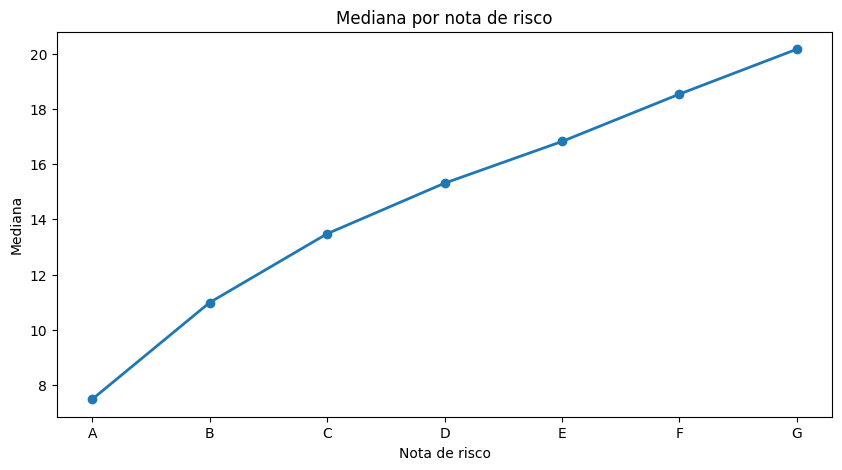

In [ ]:
Mediana_taxa = df.groupby('loan_grade')['loan_int_rate'].median()
Med_taxa=Mediana_taxa.reset_index()
plt.figure(figsize=(10,5))
plt.plot(
    Med_taxa['loan_grade'],
    Med_taxa['loan_int_rate'],
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Vendas',
)
plt.title('Mediana por nota de risco')
plt.xlabel('Nota de risco')
plt.ylabel('Mediana')
plt.show()



In [ ]:

df['loan_int_rate'] = df.apply(lambda x: Mediana_taxa[x['loan_grade']] if np.isnan(x['loan_int_rate']) else x['loan_int_rate'], axis=1)
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


**Apos a imputacao dos dados e tratamento de outliers decidiu-se gerar novamente os graficos de boxplot e histograma das variaveis numericas**

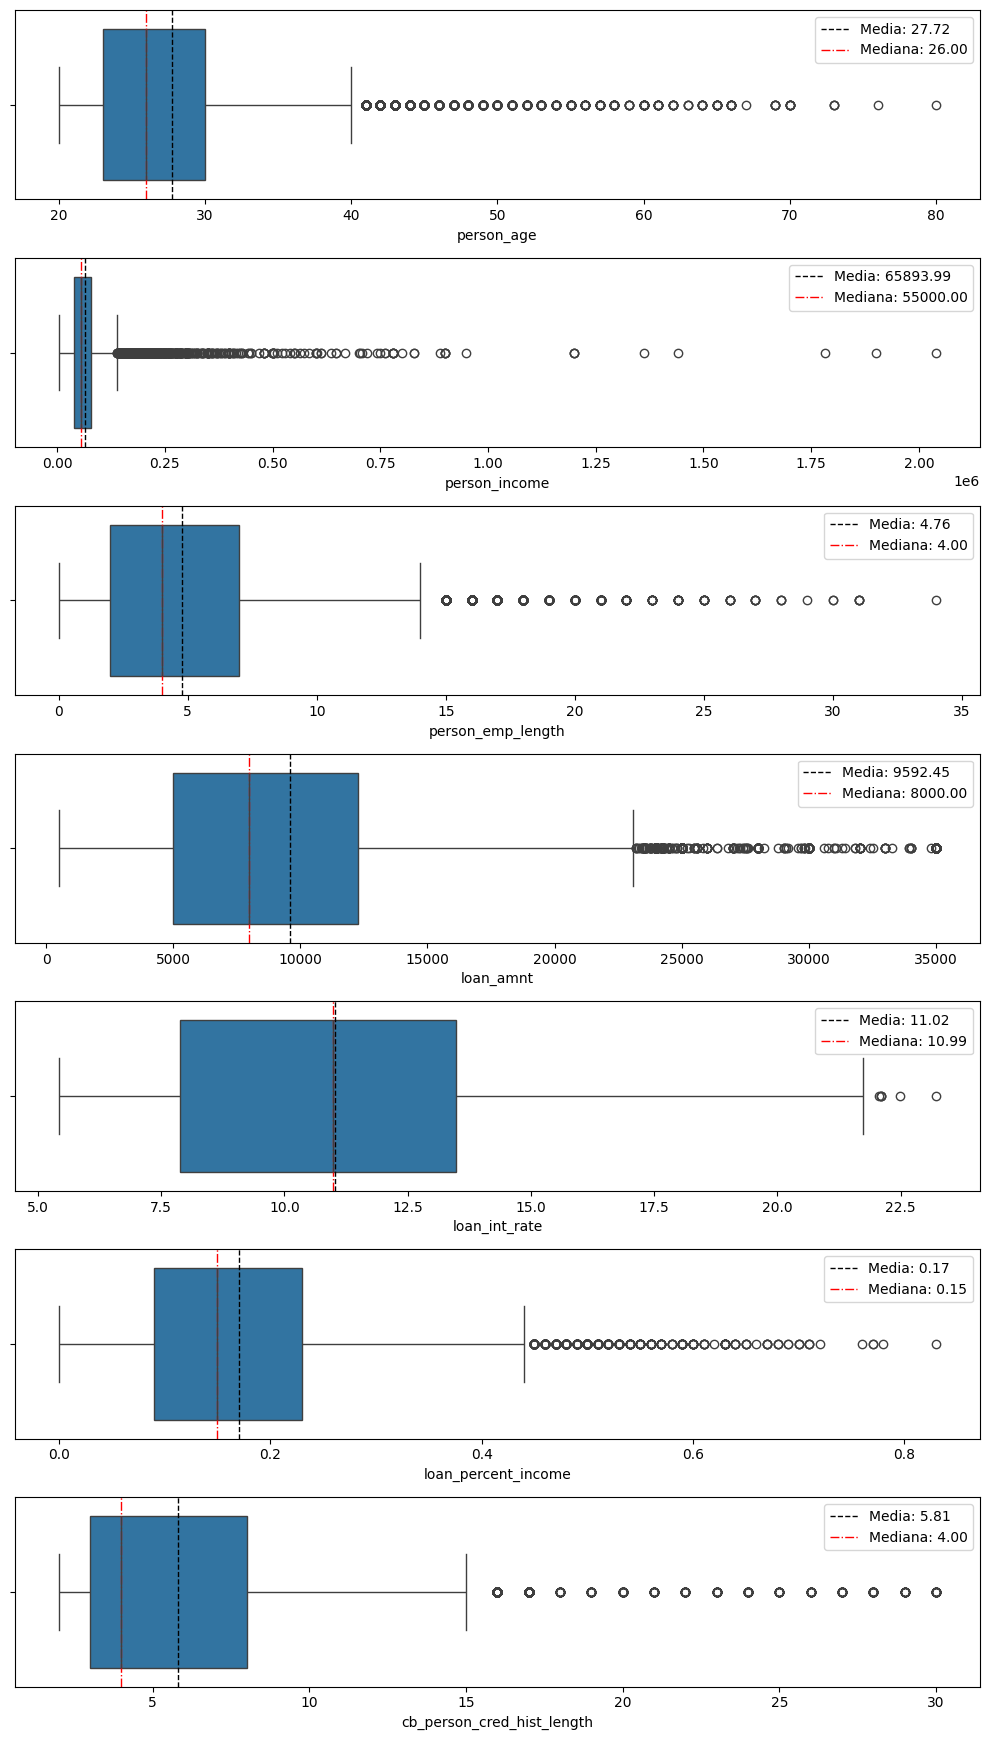

In [ ]:
# Filtrando as colunas numericas

variaveis_numericas=df.select_dtypes(include=[int,float]).columns.tolist()

# Retirando a variavel Target
variaveis_numericas.remove("loan_status")
fig,axes=plt.subplots(len(variaveis_numericas),1,figsize=(10,17.5))
i=0
for variavel in variaveis_numericas:
  sns.boxplot(data=df, x=variavel,ax=axes[i])
  axes[i].axvline(color='Black', linestyle='--',linewidth='1', x=df[variavel].mean(),label=f'Media: {df[variavel].mean():.2f}')
  axes[i].axvline(color='Red', linestyle='-.',linewidth='1', x=df[variavel].median(), label=f'Mediana: {df[variavel].median():.2f}')
  axes[i].legend()
  i+=1
plt.tight_layout()
plt.show()

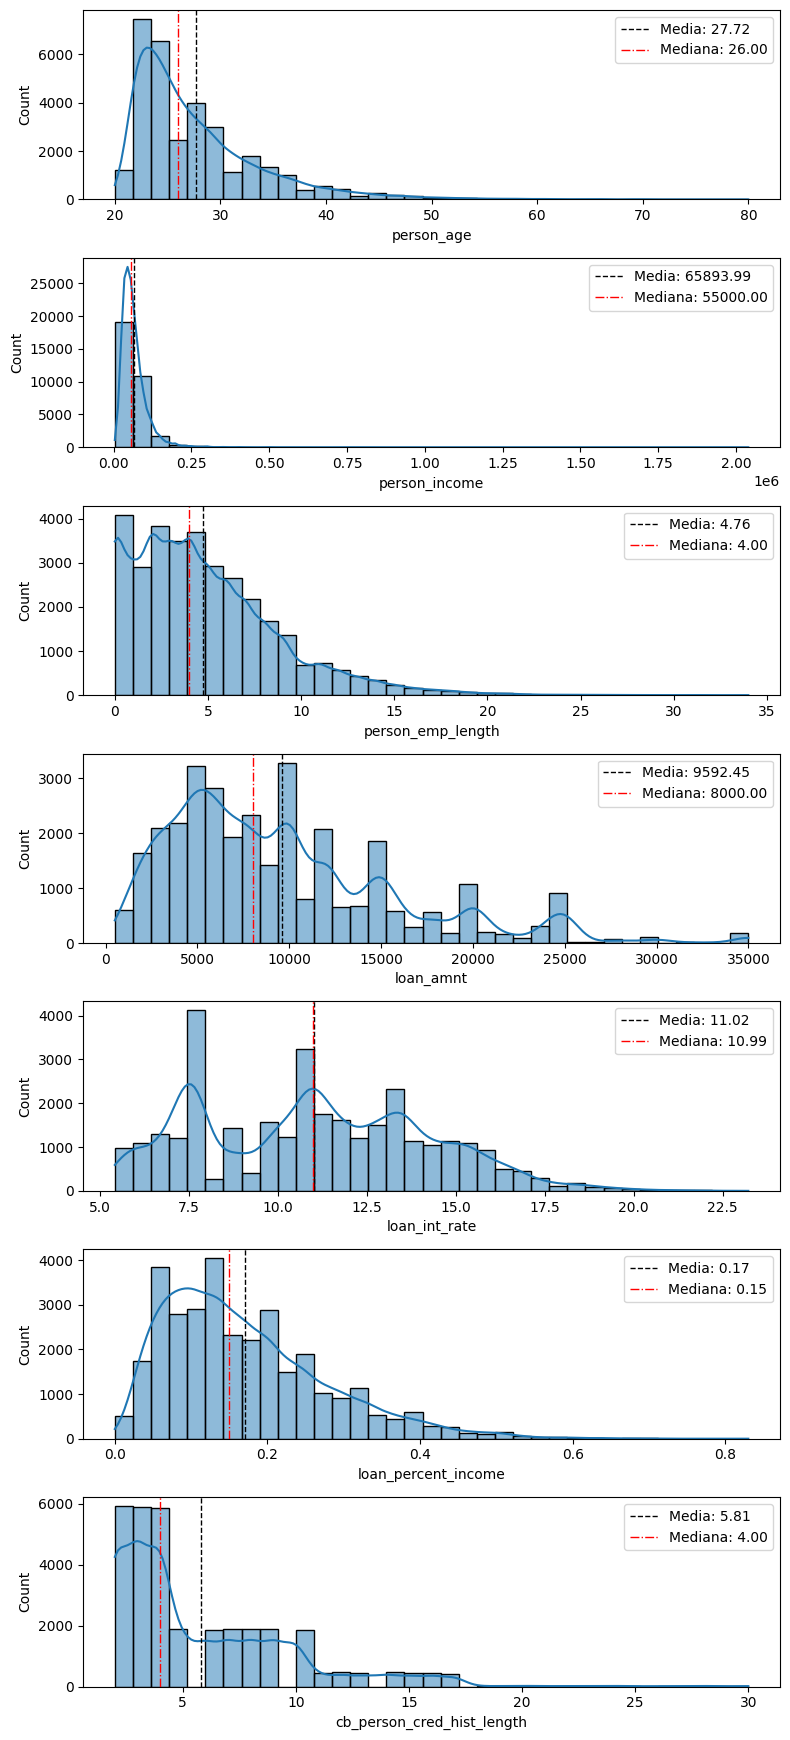

In [ ]:

fig,axes=plt.subplots(len(variaveis_numericas),1,figsize=(8,17.5))
i=0
for variavel in variaveis_numericas:
  sns.histplot(data=df, x=variavel,ax=axes[i], bins=35, kde=True)
  axes[i].axvline(color='Black', linestyle='--',linewidth='1', x=df[variavel].mean(),label=f'Media: {df[variavel].mean():.2f}')
  axes[i].axvline(color='Red', linestyle='-.',linewidth='1', x=df[variavel].median(), label=f'Mediana: {df[variavel].median():.2f}')
  axes[i].legend()
  i+=1
plt.tight_layout()
plt.show()

**Um outro ponto importante e a analise estatistica dos dados que compoem essa base de dados expondo os valores minimos, maximos, medios, e quartis. Todos os dados numericos podem ser avaliados a luz da estatistica descritiva pela funcao describe(). Os dados abaixo apresentam um resumo do ja demonstrador no boxplot.**

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32405.000000,3.240500e+04,32405.000000,32405.000000,32405.000000,32405.000000,32405.000000,32405.000000
mean,27.724641,6.589399e+04,4.758031,9592.451782,11.020186,0.218732,0.170250,5.808857
std,6.184127,5.251978e+04,3.975098,6320.880996,3.213504,0.413393,0.106788,4.052656
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.880000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,13.480000,0.000000,0.230000,8.000000
max,80.000000,2.039784e+06,34.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


# **FASE 3: FEATURE ENGINEERING (COLUNA CALCULADA)**

In [ ]:
df['comprometimento_renda']=((df['loan_amnt']/df['person_income'])*100).round(2)
df['comprometimento_renda']


,comprometimento_renda
1,10.42
2,57.29
3,53.44
4,64.34
5,25.25
...,...
32576,10.94
32577,14.69
32578,46.05
32579,10.00


**Nova conferencia nulos, duplicados**

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

# **FASE 4: SEPARACAO, BALANCEAMENTO e ESCALONAMENTO SEGURO**

In [ ]:
variaveis_nao_numericas=df.select_dtypes(include='object').columns.tolist()
variaveis_nao_numericas

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [ ]:
df[variaveis_nao_numericas].head()


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y
5,OWN,VENTURE,A,N


**Existem 4 variaveis categoricas sendo uma delas ordinais e as demais nominais:**

**Variavel Categorica Ordinal:**

**(loan_grade)-> Classificacao de risco do emprestimo pois existe hierarquia entre o risco de credito onde A e o menor risco e G e o maior risco)**

**Variáveis Categóricas Nominais:**

**person_home_ownership (Situação Habitacional)**

**loan_intent (Finalidade do Empréstimo)**

**cb_person_default_on_file (Histórico de Inadimplencia)**

**Iniciando o pre processamento das variaveis nominais aplicaremos o on hot encoding e a codificacao ordinal para a variavel ordinaria**

In [ ]:
df['loan_grade']=df['loan_grade'].map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})
df


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,comprometimento_renda
1,21,9600,OWN,5.0,EDUCATION,2,1000,11.14,0,0.10,N,2,10.42
2,25,9600,MORTGAGE,1.0,MEDICAL,3,5500,12.87,1,0.57,N,3,57.29
3,23,65500,RENT,4.0,MEDICAL,3,35000,15.23,1,0.53,N,2,53.44
4,24,54400,RENT,8.0,MEDICAL,3,35000,14.27,1,0.55,Y,4,64.34
5,21,9900,OWN,2.0,VENTURE,1,2500,7.14,1,0.25,N,2,25.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,3,5800,13.16,0,0.11,N,30,10.94
32577,54,120000,MORTGAGE,4.0,PERSONAL,1,17625,7.49,0,0.15,N,19,14.69
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,2,35000,10.99,1,0.46,N,28,46.05
32579,56,150000,MORTGAGE,5.0,PERSONAL,2,15000,11.48,0,0.10,N,26,10.00


**Aplicacao do ON HOT ENCODING para as variaveis categoricas nominais**

In [ ]:
variaveis_nao_numericas.remove('loan_grade')
variaveis_nominais=variaveis_nao_numericas
df=pd.get_dummies(
    df,
    prefix=None,
    prefix_sep="_",
    dummy_na=False,
    columns=variaveis_nominais,
    sparse=False,
    drop_first=True,
    dtype=int,
)

In [ ]:
df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
1,21,9600,5.0,2,1000,11.14,0,0.10,2,10.42,0,1,0,1,0,0,0,0,0
2,25,9600,1.0,3,5500,12.87,1,0.57,3,57.29,0,0,0,0,0,1,0,0,0
3,23,65500,4.0,3,35000,15.23,1,0.53,2,53.44,0,0,1,0,0,1,0,0,0
4,24,54400,8.0,3,35000,14.27,1,0.55,4,64.34,0,0,1,0,0,1,0,0,1
5,21,9900,2.0,1,2500,7.14,1,0.25,2,25.25,0,1,0,0,0,0,0,1,0


**Separando os dados em Features (X) e Tagets (y)**

Com o objetivo de se verificar dentro das antigas variaveis numericas se alguma coluna pode ser retirada reduzindo o efeito da multicolinearidade sera novamente plotado as correlacoes das variaveis numericas.

In [ ]:

df=df.drop(columns=['loan_amnt','person_income'])
coluna_numer=df.select_dtypes(include=['float','int']).columns.tolist()



In [ ]:

cor=df[coluna_numer].corr()
cor

,person_age,person_emp_length,loan_grade,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
person_age,1.000000,0.169246,0.013328,0.011280,-0.021345,-0.041563,0.878516,-0.041416,-0.008199,-0.000393,-0.031817,-0.092459,0.076845,0.020364,0.033750,-0.013181,0.007070
person_emp_length,0.169246,1.000000,-0.047011,-0.052716,-0.086142,-0.058485,0.146515,-0.057263,-0.015003,0.024484,-0.232842,-0.037737,0.031364,-0.002442,0.008211,0.009764,-0.029177
loan_grade,0.013328,-0.047011,1.000000,0.937641,0.373394,0.122713,0.014305,0.128124,0.018345,-0.017063,0.120163,-0.008251,0.029670,0.001022,-0.006661,-0.010802,0.536732
loan_int_rate,0.011280,-0.052716,0.937641,1.000000,0.334103,0.120451,0.015303,0.125206,0.019817,-0.013589,0.137439,-0.007512,0.022132,0.004066,-0.004272,-0.010010,0.503572
loan_status,-0.021345,-0.086142,0.373394,0.334103,1.000000,0.379592,-0.016158,0.386114,0.012831,-0.101958,0.238137,-0.055446,0.036581,0.056715,-0.021628,-0.078184,0.179220
loan_percent_income,-0.041563,-0.058485,0.122713,0.120451,0.379592,1.000000,-0.031203,0.998939,0.011203,0.050840,0.116647,-0.000370,-0.015688,0.013500,-0.003898,0.000777,0.035906
cb_person_cred_hist_length,0.878516,0.146515,0.014305,0.015303,-0.016158,-0.031203,1.000000,-0.031165,-0.006633,0.005132,-0.026251,-0.078207,0.058949,0.015633,0.035050,-0.008302,0.004512
comprometimento_renda,-0.041416,-0.057263,0.128124,0.125206,0.386114,0.998939,-0.031165,1.000000,0.011452,0.049697,0.115668,-0.002218,-0.017443,0.021561,-0.005566,-0.000961,0.038298
person_home_ownership_OTHER,-0.008199,-0.015003,0.018345,0.019817,0.012831,0.011203,-0.006633,0.011452,1.000000,-0.016789,-0.057890,-0.005379,0.000419,-0.003827,0.000041,0.009131,0.014535
person_home_ownership_OWN,-0.000393,0.024484,-0.017063,-0.013589,-0.101958,0.050840,0.005132,0.049697,-0.016789,1.000000,-0.296145,0.005481,0.011922,-0.013131,0.002579,0.097396,-0.003633


<Axes: >

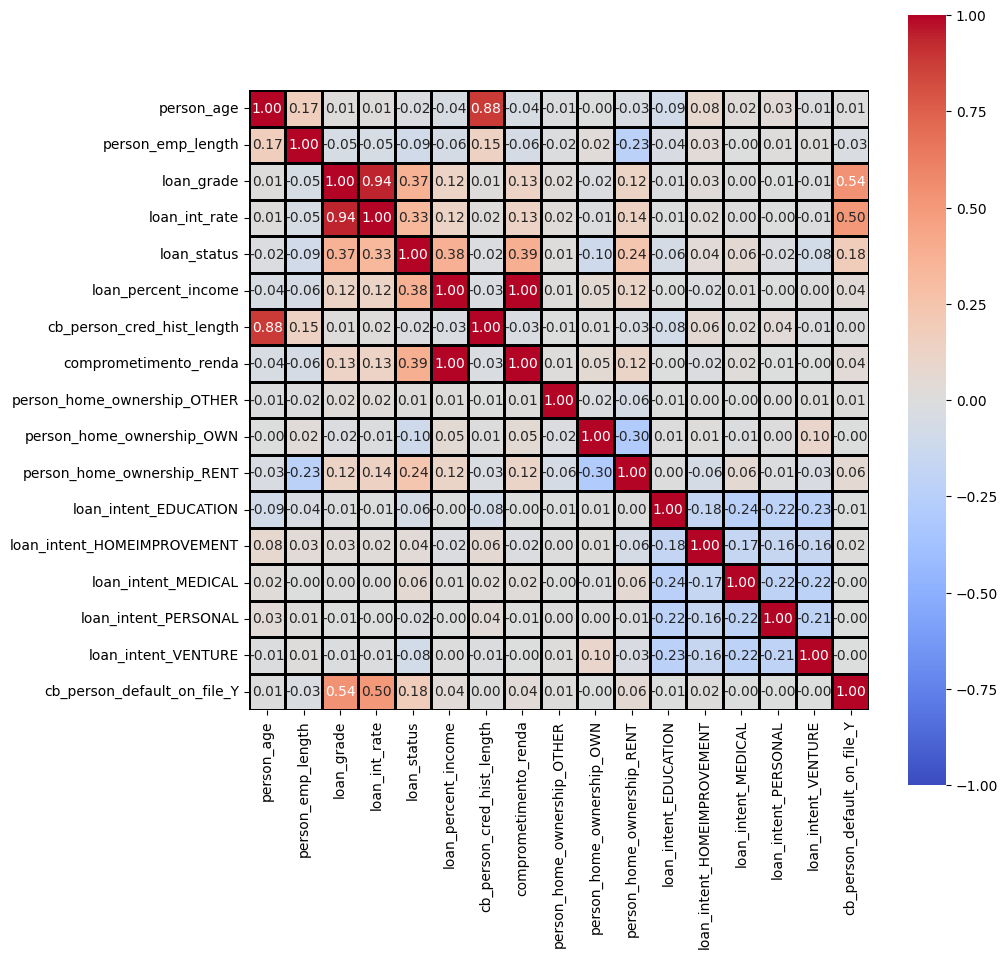

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(data=cor, annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=1,
    linecolor="black",
    square=True)

In [ ]:
#Organizacao de dados
# Separar Features (X) e Target (y)
X=df.drop(columns=['loan_status'])
y=df['loan_status']
X_arvore=X.copy()
y_arvore=y.copy()



In [ ]:
X.head()

,person_age,person_emp_length,loan_grade,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
1,21,5.0,2,11.14,0.10,2,10.42,0,1,0,1,0,0,0,0,0
2,25,1.0,3,12.87,0.57,3,57.29,0,0,0,0,0,1,0,0,0
3,23,4.0,3,15.23,0.53,2,53.44,0,0,1,0,0,1,0,0,0
4,24,8.0,3,14.27,0.55,4,64.34,0,0,1,0,0,1,0,0,1
5,21,2.0,1,7.14,0.25,2,25.25,0,1,0,0,0,0,0,1,0


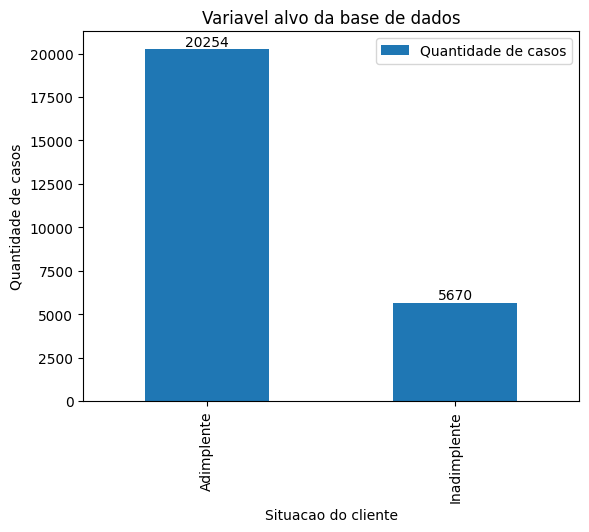

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_treino.value_counts().plot(kind='bar', legend=True)
plt.legend(['Quantidade de casos'])
plt.title ('Variavel alvo da base de dados')
plt.xlabel('Situacao do cliente')
plt.ylabel('Quantidade de casos')
plt.xticks([0,1],['Adimplente','Inadimplente'])
plt.bar_label(plt.gca().containers[0])
plt.show()

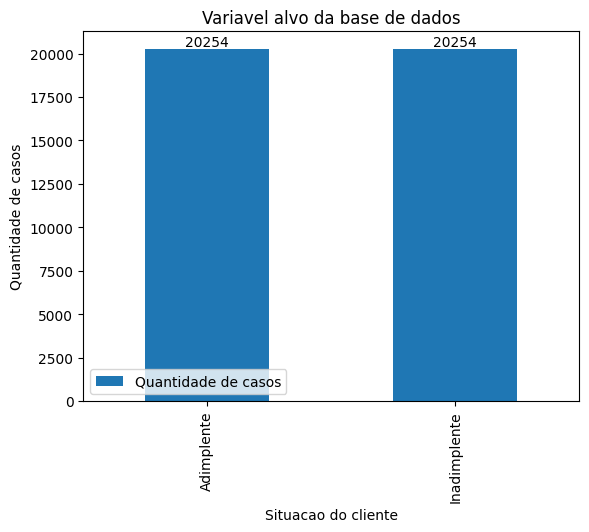

In [ ]:
#APLICANDO O SMOTE (GERAÇÃO INTELIGENTE DE DADOS SINTÉTICOS)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_treino, y_treino)
y_smote.value_counts().plot(kind='bar', legend=True)
plt.legend(['Quantidade de casos'])
plt.title ('Variavel alvo da base de dados')
plt.xlabel('Situacao do cliente')
plt.ylabel('Quantidade de casos')
plt.xticks([0,1],['Adimplente','Inadimplente'])
plt.bar_label(plt.gca().containers[0])
plt.show()

In [ ]:
X_smote.head()

,person_age,person_emp_length,loan_grade,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,23,0.0,4,15.28,0.15,4,15.25,0,0,1,0,1,0,0,0,0
1,23,5.0,4,16.89,0.04,4,4.17,0,0,1,0,0,0,0,0,1
2,29,5.0,4,16.77,0.28,8,28.12,0,0,1,0,0,0,1,0,0
3,23,8.0,5,16.32,0.04,3,4.12,0,0,0,0,0,0,1,0,1
4,25,0.0,1,7.49,0.08,2,8.37,0,1,0,0,1,0,0,0,0


**Para normalizar os dados de treino sera aplicada a StandardScale, ja que a mesma forca a media ser 1 e o desvio padrao ser 0. O outro metodo de minimo e maximo forca o menor valor ser 0 e o maior valor ser 1 sendo altamente susceptivel a outliers.**

**Por que padronizar é essencial no KNN? O algoritmo KNN baseia suas decisões na distância euclidiana entre os pontos de dados. Se uma variável possui valores muito grandes (ex: proline varia entre 300 e 1600) e outra possui valores pequenos (ex: nonflavanoid_phenols varia entre 0.1 e 0.6), a variável de maior magnitude dominará o cálculo da distância.**

In [ ]:
X_smote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40508 entries, 0 to 40507
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   40508 non-null  int64  
 1   person_emp_length            40508 non-null  float64
 2   loan_grade                   40508 non-null  int64  
 3   loan_int_rate                40508 non-null  float64
 4   loan_percent_income          40508 non-null  float64
 5   cb_person_cred_hist_length   40508 non-null  int64  
 6   comprometimento_renda        40508 non-null  float64
 7   person_home_ownership_OTHER  40508 non-null  int64  
 8   person_home_ownership_OWN    40508 non-null  int64  
 9   person_home_ownership_RENT   40508 non-null  int64  
 10  loan_intent_EDUCATION        40508 non-null  int64  
 11  loan_intent_HOMEIMPROVEMENT  40508 non-null  int64  
 12  loan_intent_MEDICAL          40508 non-null  int64  
 13  loan_intent_PERS

In [ ]:
#Aplicando normalizacao para uso no KNN
# 4. Ajustando E transformando os dados de TREINO
scaler=StandardScaler()
X_smote= scaler.fit_transform(X_smote)

# 5. Apenas transformando os dados de TESTE (Evita vazamento de dados)
X_teste= scaler.transform(X_teste)


In [ ]:
X_smote

array([[-0.72685075, -1.16701456,  1.24990755, ..., -0.37572178,
        -0.37537945, -0.46029447],
       [-0.72685075,  0.11978477,  1.24990755, ..., -0.37572178,
        -0.37537945,  2.1725223 ],
       [ 0.249207  ,  0.11978477,  1.24990755, ...,  2.66154384,
        -0.37537945, -0.46029447],
       ...,
       [-0.40149816, -0.39493496,  1.24990755, ..., -0.37572178,
        -0.37537945, -0.46029447],
       [-0.40149816,  0.27460199,  1.24990755, ..., -0.37572178,
        -0.37537945, -0.46029447],
       [ 0.08653071, -0.09657229,  2.05788749, ..., -0.37572178,
        -0.37537945, -0.46029447]])

**Para conferir a padronizacao utilizou-se novamente o describe para conferir se as variaveis ficaram com media 0 e desvio padrao 1**

**Foi utilizada a padronizacao separada para os dados de treino e teste para evitar vazamento de informacoes do treino para o teste.**